# 01 — EDA: Instacart Online Grocery

**Proyecto:** Insight Commerce — Next-Basket Recommendation  
**Dataset:** Instacart Online Grocery Basket Analysis  
**Objetivo:** Explorar la estructura, patrones de compra y riesgos del dataset.

| Sección | Contenido |
|---------|-----------|
| 0 | Configuración y carga |
| 1 | Estructura del dataset |
| 2 | Comportamiento de compra |
| 3 | Análisis de recompra |
| 4 | Productos y categorías |
| 5 | Sparsity y cold start |
| 6 | Conclusiones y alertas para DS-2 |

---

## Sección 0 - Configuración y carga

In [1]:
import os
import warnings
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════
#  PARÁMETROS CONFIGURABLES — modificar según necesidad
# ══════════════════════════════════════════════════════════
DATA_PATH    = Path('../data/raw')         # carpeta con los CSVs de Instacart
OUTPUT_PATH  = Path('../reports')          # carpeta de reportes
FIG_DIR      = OUTPUT_PATH / 'figures'

MVP_MODE     = True        # True = muestra reducida | False = dataset completo
N_USUARIOS   = 50_000      # # usuarios a samplear si MVP_MODE = True
RANDOM_STATE = 42
MIN_COMPRAS  = 50          # mínimo de compras para tasas de recompra por producto

# ── Configuración de visualizaciones ───────────────────────
OUTPUT_PATH.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi']     = 100

print(f'Modo: {"MVP (" + str(N_USUARIOS) + " usuarios)" if MVP_MODE else "FULL (dataset completo)"}'  )
print(f'Output: {OUTPUT_PATH.resolve()}')

Modo: MVP (50000 usuarios)
Output: C:\Users\feder\Documents\Data_Science\mProyectoFinal\insight-commerce-recsys\reports


### Carga de datos

Las tablas de dimensiones (`products`, `aisles`, `departments`) se cargan completas.
Para las tablas de hechos se realiza un muestreo estratificado por usuario para
mantener la coherencia: todas las órdenes de un usuario muestreado se incluyen.

In [2]:
# ── Tablas de dimensiones: carga completa ──────────────────
products    = pd.read_csv(os.path.join(DATA_PATH, 'products.csv'))
aisles      = pd.read_csv(os.path.join(DATA_PATH, 'aisles.csv'))
departments = pd.read_csv(os.path.join(DATA_PATH, 'departments.csv'))

# ── Optimización de dtypes en dimensiones ──────────────────
products['product_id']   = products['product_id'].astype('int64')
products['aisle_id']     = products['aisle_id'].astype('int64')
products['department_id']= products['department_id'].astype('int64')
aisles['aisle_id']       = aisles['aisle_id'].astype('int64')
departments['department_id'] = departments['department_id'].astype('int64')

# ── Orders: muestreo por usuario ───────────────────────────
orders_full = pd.read_csv(os.path.join(DATA_PATH, 'orders.csv'),
                          dtype={'order_id': 'int64', 'user_id': 'int64',
                                 'order_number': 'int64', 'order_dow': 'int64',
                                 'order_hour_of_day': 'int64'})

if N_USUARIOS is not None:
    usuarios_muestra = (orders_full['user_id']
                        .drop_duplicates()
                        .sample(n=N_USUARIOS, random_state=RANDOM_STATE))
    orders = orders_full[orders_full['user_id'].isin(usuarios_muestra)].copy()
else:
    orders = orders_full.copy()

order_ids_muestra = set(orders['order_id'].unique())

# ── Tablas de hechos: filtrar por órdenes de la muestra ────
order_products_prior = pd.read_csv(
    os.path.join(DATA_PATH, 'order_products__prior.csv'),
    dtype={'order_id': 'int64', 'product_id': 'int64',
           'add_to_cart_order': 'int64', 'reordered': 'int64'})
order_products_prior = order_products_prior[
    order_products_prior['order_id'].isin(order_ids_muestra)].copy()

order_products_train = pd.read_csv(
    os.path.join(DATA_PATH, 'order_products__train.csv'),
    dtype={'order_id': 'int64', 'product_id': 'int64',
           'add_to_cart_order': 'int64', 'reordered': 'int64'})
order_products_train = order_products_train[
    order_products_train['order_id'].isin(order_ids_muestra)].copy()

# ── Tablas de dimensiones enriquecidas ────────────────────
products_full = (products
                 .merge(aisles, on='aisle_id')
                 .merge(departments, on='department_id'))


# ── Join consolidado: tabla de hechos enriquecida ──────────
# Se usa para análisis de productos, categorías y recompra (sección 2 y 5).
# NO incluye order_products_train para evitar data leakage.
df = (order_products_prior
      .merge(orders[['order_id', 'user_id', 'order_number',
                      'order_dow', 'order_hour_of_day',
                      'days_since_prior_order']], on='order_id')
      .merge(products[['product_id', 'product_name', 'aisle_id', 'department_id']], on='product_id')
      .merge(departments[['department_id', 'department']], on='department_id')
      .merge(aisles[['aisle_id', 'aisle']], on='aisle_id'))

# ── Métricas pre-calculadas reutilizables ────────────────────────────────────
ordenes_por_usuario = orders.groupby('user_id')['order_id'].count()

# ── Acumulador del reporte de calidad ─────────────────────
quality_report = {}

print("✓ Carga y join exitosos")
print(f"  Usuarios en muestra:            {orders['user_id'].nunique():>10,}")
print(f"  Órdenes en muestra:             {orders['order_id'].nunique():>10,}")
print(f"  Registros order_products_prior: {len(order_products_prior):>10,}")
print(f"  Registros order_products_train: {len(order_products_train):>10,}")
print(f"  Registros en df consolidado:    {len(df):>10,}")
print(f"  Productos (catálogo completo):  {len(products):>10,}")
print(f"  Memoria df consolidado:         {df.memory_usage(deep=True).sum() / 1e6:>9.1f} MB")

✓ Carga y join exitosos
  Usuarios en muestra:                50,000
  Órdenes en muestra:                831,128
  Registros order_products_prior:  7,927,707
  Registros order_products_train:    335,968
  Registros en df consolidado:     7,927,707
  Productos (catálogo completo):      49,688
  Memoria df consolidado:            2430.8 MB


---
## Sección 1 — Estructura del dataset

Antes de realizar cualquier análisis es necesario examinar la estructura del dataset para comprender sus características básicas. En esta etapa se revisa el número de registros por tabla, los tipos de datos de cada variable y la presencia de valores faltantes.

Esta exploración inicial permite evaluar la calidad de los datos y establecer criterios adecuados para su limpieza, transformación y posterior análisis.

In [3]:
# ── Estructura de los datos ───────────────────────────

for nombre, tabla in [('orders', orders),
                      ('order_products_prior', order_products_prior),
                      ('order_products_train', order_products_train),
                      ('products', products),
                      ('aisles', aisles),
                      ('departments', departments)]:
    print(f"\n{'='*45}")
    print(f"  Tabla: {nombre}")
    print(f"  Filas: {tabla.shape[0]:,}  |  Columnas: {tabla.shape[1]}")
    nulos = tabla.isnull().sum()
    nulos = nulos[nulos > 0]
    print(f"  Nulos:\n{nulos}" if len(nulos) > 0 else "  Nulos: ninguno")
    print(tabla.dtypes.to_string())

print(f"\n{'='*45}")
print(f"Resumen general")
print(f"  Usuarios únicos:   {orders['user_id'].nunique():,}")
print(f"  Órdenes únicas:    {orders['order_id'].nunique():,}")
print(f"  Productos únicos:  {products['product_id'].nunique():,}")
print(f"  Departamentos:     {departments['department_id'].nunique()}")
print(f"  Pasillos:          {aisles['aisle_id'].nunique()}")

# Verificación de duplicados
dup_prior = order_products_prior.duplicated(subset=['order_id', 'product_id']).sum()
dup_train = order_products_train.duplicated(subset=['order_id', 'product_id']).sum()
print(f"\nDuplicados (order_id, product_id):")
print(f"  order_products_prior: {dup_prior:,}")
print(f"  order_products_train: {dup_train:,}")


  Tabla: orders
  Filas: 831,128  |  Columnas: 7
  Nulos:
days_since_prior_order    50000
dtype: int64
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64

  Tabla: order_products_prior
  Filas: 7,927,707  |  Columnas: 4
  Nulos: ninguno
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64

  Tabla: order_products_train
  Filas: 335,968  |  Columnas: 4
  Nulos: ninguno
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64

  Tabla: products
  Filas: 49,688  |  Columnas: 4
  Nulos: ninguno
product_id        int64
product_name     object
aisle_id          int64
department_id     int64

  Tabla: aisles
  Filas: 134  |  Columnas: 2
  Nulos: ninguno
aisle_id     int64
aisle       object

  Tabla: dep

### **Resultados**

La muestra cargada representa 50.000 usuarios con 831.128 órdenes y 7.927.707 registros en el historial de compras (order_products_prior). El catálogo de productos es completo con 49.688 productos distribuidos en 21 departamentos y 134 pasillos.

- #### *Observación sobre nulos*
`days_since_prior_order` tiene exactamente un nulo por usuario — su primera orden, que por definición no tiene orden anterior. Es un **nulo estructural esperado**, no un problema de calidad.

- #### *Columna `eval_set`*
Clasifica cada orden en `prior` (historial), `train` (target del modelo) o `test` (evaluación Kaggle sin ground truth). Esta columna es metadata de la competencia — no es una variable de negocio y no se usará como feature.

---
## Sección 2 — Comportamiento de compra

Comprender el comportamiento de compra de los usuarios es el punto de partida para construir un sistema de recomendación con impacto real. La frecuencia con la que un usuario ordena, la cantidad de productos que lleva por orden y los momentos en que elige comprar no son simplemente estadísticas descriptivas — son señales que determinan cuándo y cómo el sistema puede influir en la decisión de compra.

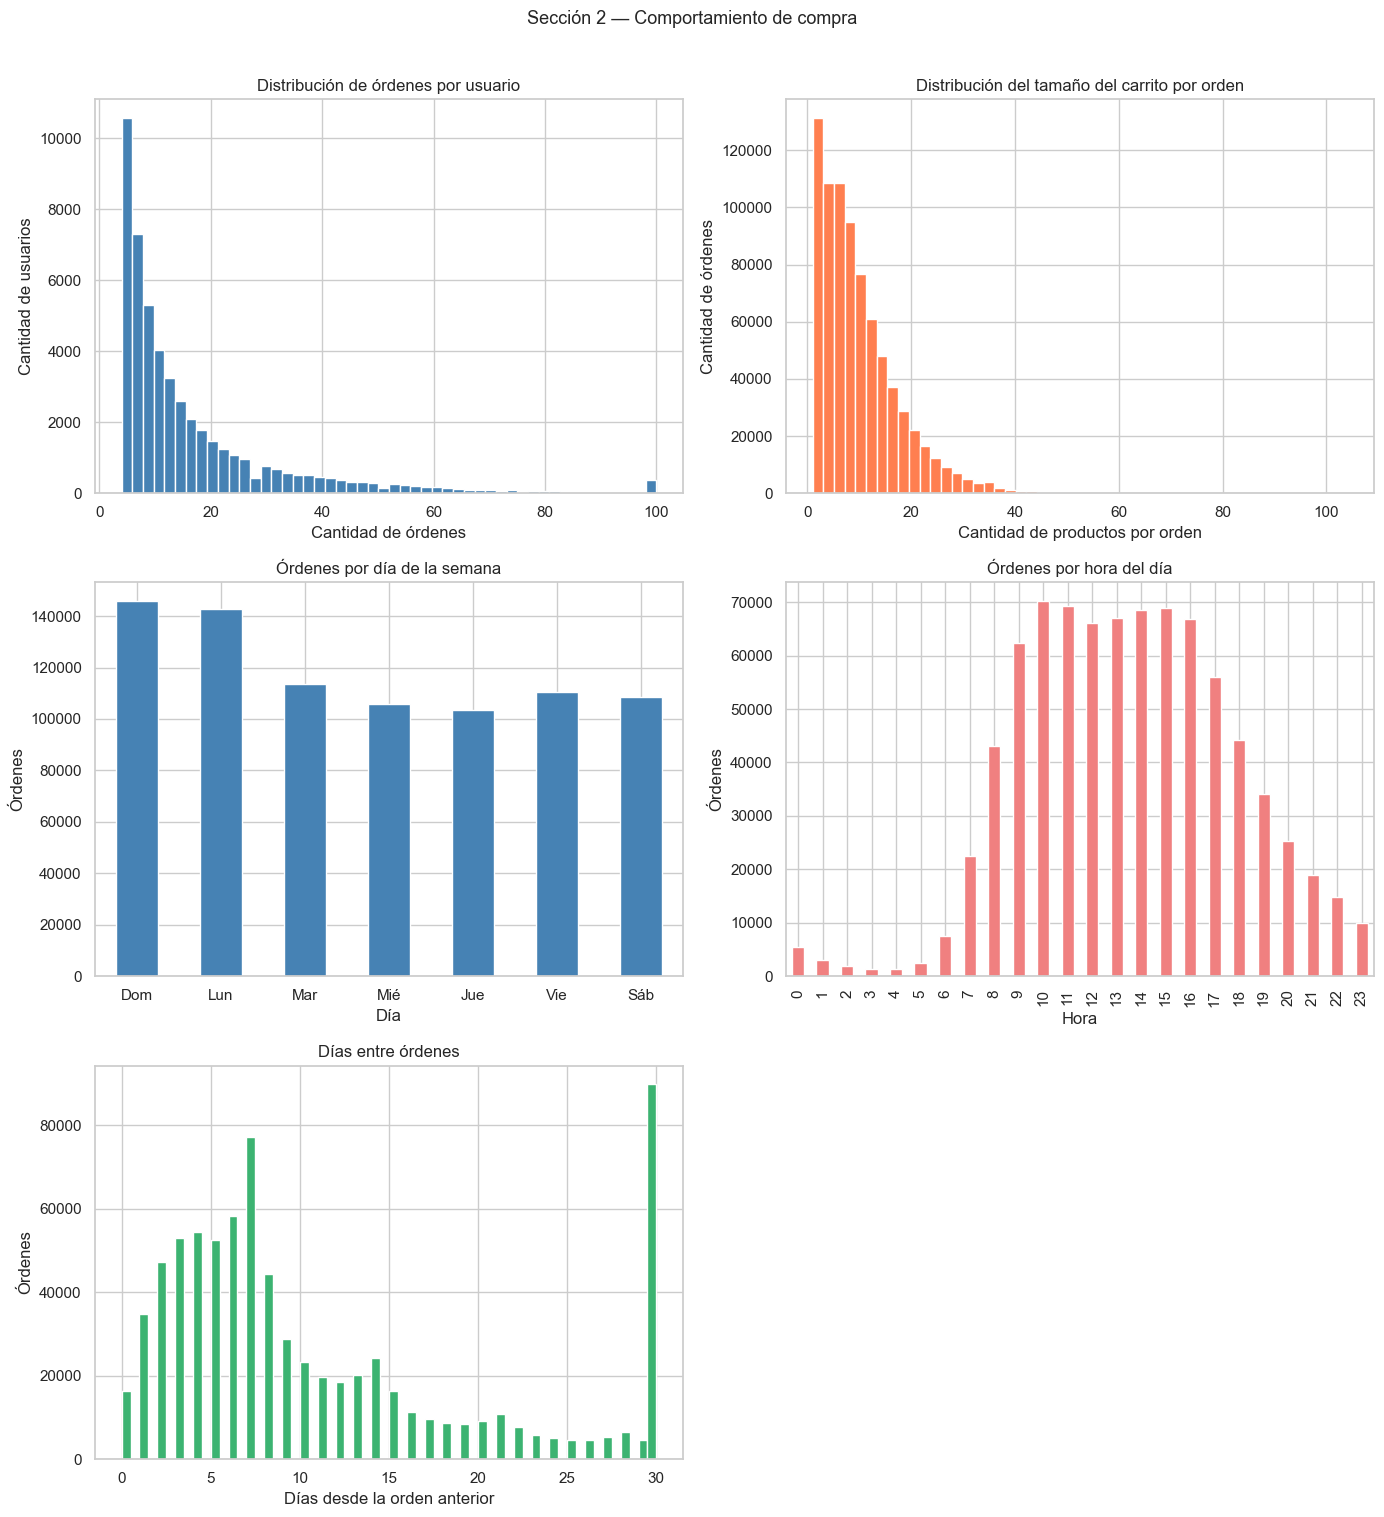

Órdenes por usuario — mediana: 10  |  media: 16.6  |  máx: 100
Productos por orden — mediana: 8  |  media: 10.1  |  máx: 104
Días entre órdenes  — mediana: 7  |  media: 11.1

Cold start:
  Usuarios con 1 sola orden:     0
  Usuarios con < 5 órdenes:      5,736
  Usuarios con >= 10 órdenes:    26,821


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# — Distribución de órdenes por usuario
ordenes_por_usuario.plot(
    kind='hist', bins=50, color='steelblue', edgecolor='white', ax=axes[0,0])
axes[0,0].set_title('Distribución de órdenes por usuario')
axes[0,0].set_xlabel('Cantidad de órdenes')
axes[0,0].set_ylabel('Cantidad de usuarios')

# — Tamaño del carrito
tam_carrito = order_products_prior.groupby('order_id')['product_id'].count()

tam_carrito.plot(
    kind='hist', bins=50, color='coral', edgecolor='white', ax=axes[0,1])
axes[0,1].set_title('Distribución del tamaño del carrito por orden')
axes[0,1].set_xlabel('Cantidad de productos por orden')
axes[0,1].set_ylabel('Cantidad de órdenes')

# — Día de la semana con mayor volumen de órdenes
dias = {0:'Dom', 1:'Lun', 2:'Mar', 3:'Mié', 4:'Jue', 5:'Vie', 6:'Sáb'}
orders['order_dow'].value_counts().sort_index().rename(index=dias).plot(
    kind='bar', color='steelblue', edgecolor='white', ax=axes[1,0])
axes[1,0].set_title('Órdenes por día de la semana')
axes[1,0].set_xlabel('Día')
axes[1,0].set_ylabel('Órdenes')
axes[1,0].tick_params(axis='x', rotation=0)

# - Hora del día con mayor volumen de órdenes

horas = orders['order_hour_of_day'].value_counts().sort_index()
horas.plot(
    kind='bar', color='lightcoral', edgecolor='white', ax=axes[1,1])
axes[1,1].set_title('Órdenes por hora del día')
axes[1,1].set_xlabel('Hora')
axes[1,1].set_ylabel('Órdenes')

# — Recencia entre órdenes
recencia = orders['days_since_prior_order'].dropna()
recencia.plot(
    kind='hist', bins=60, color='mediumseagreen', edgecolor='white', ax=axes[2,0])
axes[2,0].set_title('Días entre órdenes')
axes[2,0].set_xlabel('Días desde la orden anterior')
axes[2,0].set_ylabel('Órdenes')

plt.suptitle('Sección 2 — Comportamiento de compra', fontsize=13, y=1.01)
# eliminar el subplot vacío
fig.delaxes(axes[2,1])
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_comportamiento_compra.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Órdenes por usuario — mediana: {ordenes_por_usuario.median():.0f}  |  media: {ordenes_por_usuario.mean():.1f}  |  máx: {ordenes_por_usuario.max()}")
print(f"Productos por orden — mediana: {tam_carrito.median():.0f}  |  media: {tam_carrito.mean():.1f}  |  máx: {tam_carrito.max()}")
print(f"Días entre órdenes  — mediana: {recencia.median():.0f}  |  media: {recencia.mean():.1f}")
print(f"\nCold start:")
print(f"  Usuarios con 1 sola orden:     {(ordenes_por_usuario == 1).sum():,}")
print(f"  Usuarios con < 5 órdenes:      {(ordenes_por_usuario < 5).sum():,}")
print(f"  Usuarios con >= 10 órdenes:    {(ordenes_por_usuario >= 10).sum():,}")

### **Resultados**
- #### *Distribución de órdenes por usuario*
La distribución tiene una forma de cola larga hacia la derecha, con la
mayoría de los usuarios concentrados entre 4 y 20 órdenes. La mediana
es de 10 órdenes y el promedio de 16.6, lo que indica que un grupo de
usuarios muy activos (con hasta 100 órdenes) eleva el promedio.

**Implicancia para el modelo:** usuarios con pocas órdenes tienen menos
historial disponible para construir features confiables — esto es el
problema de cold start que deberá manejar DS-2 en el feature engineering.

- #### *Distribución del tamaño del carrito*
El carrito promedio tiene 10.1 productos y la mediana es 8, con una
distribución que también tiene cola derecha. La gran mayoría de las
órdenes tienen entre 1 y 20 productos.

**Implicancia para el modelo:** el tamaño promedio del carrito es el
baseline de negocio contra el que se medirá el Basket Size Uplift.
Si el modelo logra que usuarios compren más productos por orden,
ese delta es el valor directo que genera el sistema de recomendación.

- #### *Temporalidad de las compras*
Domingo y lunes concentran el mayor volumen de órdenes, con una caída
progresiva hacia mediados de semana. En cuanto a la hora del día, el
horario pico es entre las 10 y las 16 hs, con volumen casi nulo entre
las 0 y las 6 hs.

**Implicancia para el modelo:** `order_dow` y `order_hour_of_day` son
features temporales con señal real — el día y la hora en que un usuario
suele comprar es información útil para predecir su próxima compra.

- #### *Recencia entre compras*
El promedio de días entre órdenes revela el ciclo de recompra típico
del usuario. Esta variable es clave para el modelo: si un usuario
compra cada 7 días y su última compra fue hace 6 días, es probable
que esté cerca de su próxima orden.


---
## Sección 3 — Análisis de recompra

La recompra es el núcleo del problema. Un sistema de next-basket recommendation busca predecir qué productos volverá a comprar un usuario en su próxima orden. Analizar la tasa de recompra —tanto a nivel global como por producto y por usuario— permite evaluar qué tan predecible es el comportamiento de compra y qué tan fuerte es la señal disponible para que el modelo aprenda.

Tasa global de recompra: 59.01%
→ De cada 10 productos en un carrito, 5.9 son recompras


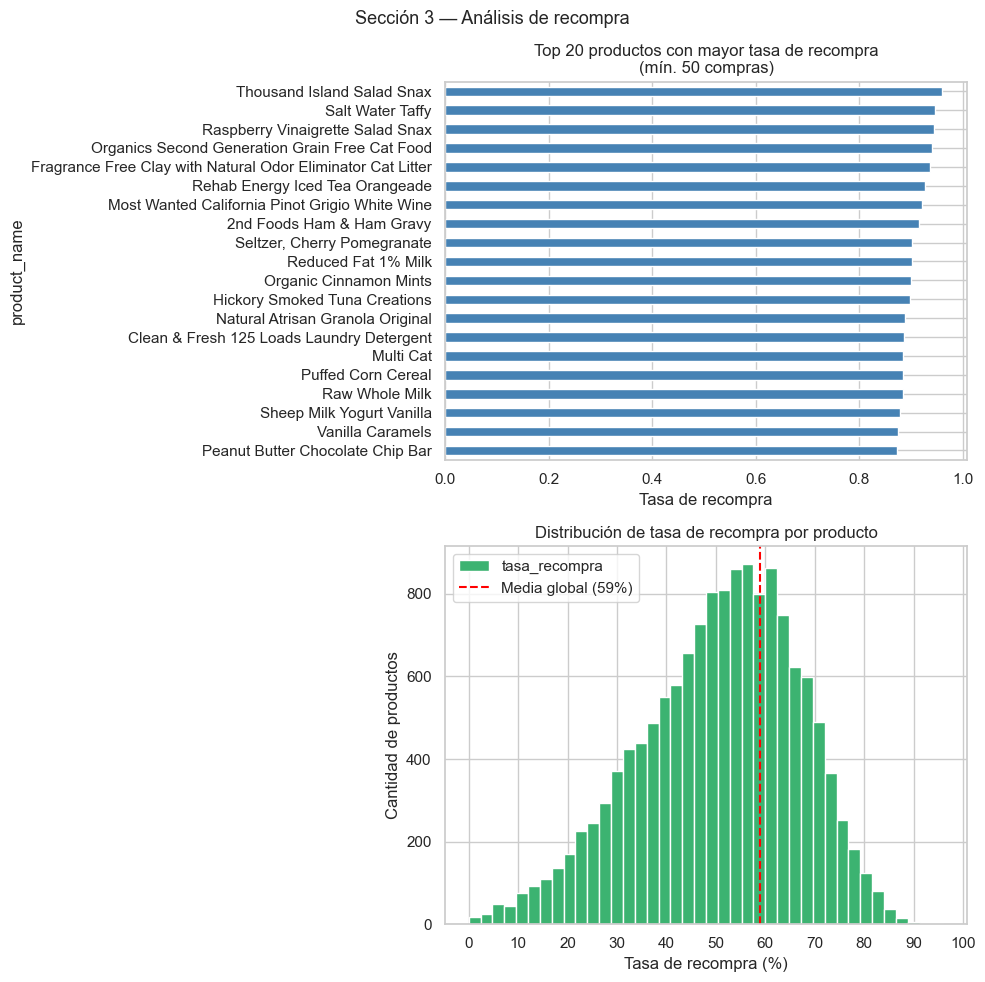

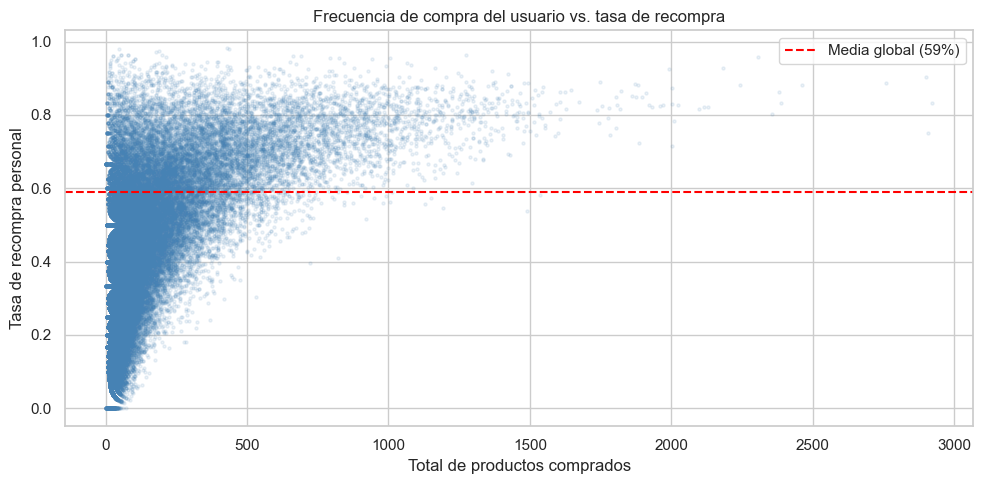

In [5]:
# ── Tasa global ────────────────────────────────────────────
tasa_global = df['reordered'].mean()
print(f"Tasa global de recompra: {tasa_global:.2%}")
print(f"→ De cada 10 productos en un carrito, {tasa_global*10:.1f} son recompras")

# ── Tasa por producto (con filtro mínimo) ──────────────────
tasa_por_producto = (df.groupby(['product_id', 'product_name'])['reordered']
                     .agg(['mean', 'count'])
                     .reset_index()
                     .rename(columns={'mean': 'tasa_recompra', 'count': 'total_compras'}))

# Filtrar productos con mínimo de compras para que la tasa sea representativa y no esté sesgada por productos poco comprados.
# MIN_COMPRAS es un parámetro configurable al inicio del notebook.
tasa_por_producto = tasa_por_producto[tasa_por_producto['total_compras'] >= MIN_COMPRAS]

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Top 20 productos
top20 = tasa_por_producto.sort_values('tasa_recompra', ascending=False).head(20)

top20.plot(kind='barh', x='product_name', y='tasa_recompra',
           color='steelblue', legend=False, ax=axes[0])
axes[0].set_title(f'Top 20 productos con mayor tasa de recompra\n(mín. {MIN_COMPRAS} compras)')
axes[0].set_xlabel('Tasa de recompra')
axes[0].invert_yaxis()

# Distribución de tasa de recompra por producto (en porcentaje para mejor interpretación)
(tasa_por_producto['tasa_recompra'] * 100).plot(
    kind='hist', bins=40, color='mediumseagreen', edgecolor='white', ax=axes[1])
axes[1].set_title('Distribución de tasa de recompra por producto')
axes[1].set_xlabel('Tasa de recompra (%)')
axes[1].set_ylabel('Cantidad de productos')
axes[1].set_xticks(range(0, 101, 10))
axes[1].axvline(tasa_global * 100, color='red', linestyle='--', label=f'Media global ({tasa_global:.0%})')
axes[1].legend()

plt.suptitle('Sección 3 — Análisis de recompra', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_recompra_productos.png'), dpi=150)
plt.show()

# ── Scatterplot frecuencia del usuario vs. tasa de recompra ─
frecuencia_usuario = (df.groupby('user_id')
                       .agg(total_productos=('product_id', 'count'),
                            tasa_recompra=('reordered', 'mean'))
                       .reset_index())

plt.figure(figsize=(10, 5))
plt.scatter(frecuencia_usuario['total_productos'],
            frecuencia_usuario['tasa_recompra'],
            alpha=0.1, color='steelblue', s=5)
plt.axhline(tasa_global, color='red', linestyle='--', label=f'Media global ({tasa_global:.0%})')
plt.title('Frecuencia de compra del usuario vs. tasa de recompra')
plt.xlabel('Total de productos comprados')
plt.ylabel('Tasa de recompra personal')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_frecuencia_vs_recompra.png'), dpi=150)
plt.show()

## **Resultados**

### *Tasa global de recompra*
La tasa global de recompra es del **59%**. Esto significa que de cada
10 productos que aparecen en un carrito, casi 6 son productos que el
usuario ya compró antes. Este número es muy positivo para el proyecto:
una tasa alta de recompra implica que el comportamiento de compra es
bastante predecible y que el modelo tiene señal fuerte para trabajar.

### *Top 20 productos más recomprados*
Los productos con mayor tasa de recompra superan el 90% e incluyen
productos de consumo recurrente: snacks, lácteos, alimentos para
mascotas y productos de limpieza. Estos productos tienen una demanda
casi automática — el usuario los compra casi todas las veces que hace
un pedido.

**Implicancia para el modelo:** estos productos son candidatos fuertes
para recomendaciones de alta precisión. Recomendar un producto con 95%
de tasa de recompra a un usuario que ya lo compró varias veces es casi
una recomendación garantizada.

### *Distribución de tasa de recompra por producto*
La distribución tiene forma aproximadamente normal con centro alrededor
del 50-60%. Muy pocos productos tienen tasa de recompra cercana a 0%
o al 100% — la mayoría se concentra en el rango 40-70%.

**Implicancia para el modelo:** no hay una separación binaria clara entre
"productos que se recompran" y "productos que no". El modelo necesita
aprender a ordenar los productos por probabilidad de recompra para cada
usuario específico, no solo identificar los más populares globalmente.

### *Frecuencia de compra del usuario vs. tasa de recompra*
El scatterplot muestra una nube densa en la zona de pocos productos
comprados (usuarios con poco historial) con alta varianza en la tasa de
recompra. A medida que aumenta el historial del usuario, la tasa de
recompra se estabiliza en torno al 60-70%.

**Implicancia para el modelo:** los usuarios con más historial son más
predecibles. La feature `user_total_orders` captura indirectamente
esta confiabilidad — más órdenes implica más señal disponible.


---
## Sección 4 — Productos y categorías

Analizar las compras por categoría de producto permite identificar patrones diferentes dentro del catálogo. En e-commerce, la estructura jerárquica (departamento → pasillo → producto) ayuda a crear variables agregadas que mejoran el sistema de recomendación.

Algunas categorías, como lácteos o frutas, tienen tasas de recompra más altas porque se compran con mayor frecuencia, mientras que otras se compran solo ocasionalmente. Estas diferencias hacen útil incluir variables a nivel de categoría en el modelo.

En esta sección se utiliza directamente df, el dataset consolidado creado en la celda de carga, para evitar merges innecesarios.

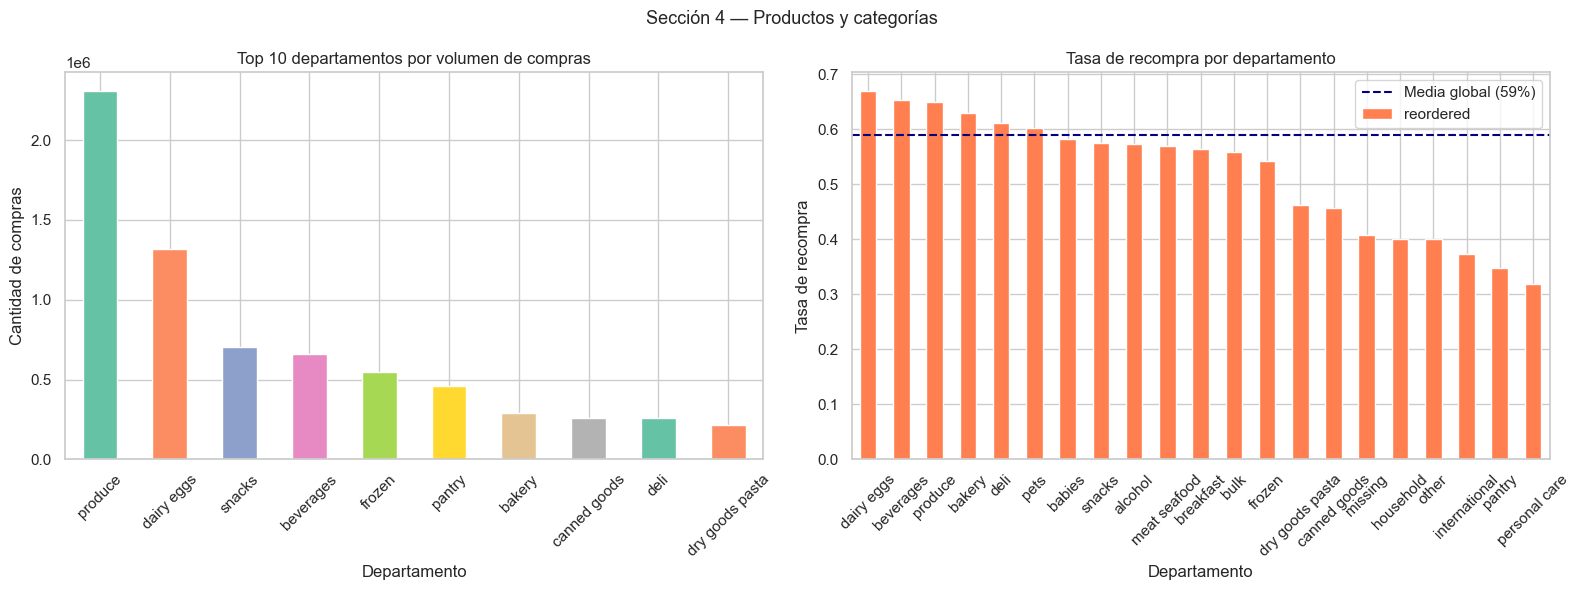


Tasa de recompra por departamento:
department
dairy eggs         67.0%
beverages          65.3%
produce            65.0%
bakery             62.9%
deli               61.1%
pets               60.2%
babies             58.2%
snacks             57.5%
alcohol            57.4%
meat seafood       57.0%
breakfast          56.5%
bulk               55.8%
frozen             54.2%
dry goods pasta    46.2%
canned goods       45.7%
missing            40.9%
household          40.1%
other              40.0%
international      37.3%
pantry             34.8%
personal care      31.8%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Top 10 departamentos por volumen
top_deptos = (df.groupby('department')['product_id']
               .count()
               .sort_values(ascending=False)
               .head(10))

colors = sns.color_palette("Set2", len(top_deptos))
top_deptos.plot(kind='bar', color=colors, edgecolor='white', ax=axes[0])
axes[0].set_title('Top 10 departamentos por volumen de compras')
axes[0].set_xlabel('Departamento')
axes[0].set_ylabel('Cantidad de compras')
axes[0].tick_params(axis='x', rotation=45)

# Tasa de recompra por departamento
recompra_depto = (df.groupby('department')['reordered']
                   .mean()
                   .sort_values(ascending=False))

recompra_depto.plot(kind='bar', color='coral', edgecolor='white', ax=axes[1])
axes[1].axhline(tasa_global, color='navy', linestyle='--', label=f'Media global ({tasa_global:.0%})')
axes[1].set_title('Tasa de recompra por departamento')
axes[1].set_xlabel('Departamento')
axes[1].set_ylabel('Tasa de recompra')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('Sección 4 — Productos y categorías', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_categorias.png'), dpi=150)
plt.show()

print("\nTasa de recompra por departamento:")
print(recompra_depto.map('{:.1%}'.format).to_string())

### **Resultados**

#### *Top 10 departamentos por volumen*
El departamento **produce** domina ampliamente con más de 2 millones de
compras, seguido por **dairy eggs** con 1.3 millones. Snacks, beverages
y frozen completan el top 5. Estos 5 departamentos concentran la gran
mayoría del volumen total de compras.

**Implicancia para el modelo:** el modelo va a tener mucha más señal
para productos de produce y dairy eggs que para departamentos de bajo
volumen. Para categorías con pocos registros, las features de popularidad
global serán menos confiables.

#### *Tasa de recompra por departamento*
**Dairy eggs** encabeza la tasa de recompra con ~67%, seguido de
**beverages** (~65%) y **produce** (~65%). En el extremo opuesto,
**personal care** (~32%) y **pantry** (~38%) tienen tasas
significativamente menores.

Esto tiene lógica de negocio clara: la leche, el jugo y las frutas
son compras recurrentes casi automáticas, mientras que los productos
de cuidado personal o despensa se compran más esporádicamente o se
varían más entre compras.

**Implicancia para el modelo:** una feature de tasa de recompra
promedio por departamento puede ser útil como señal adicional para
el modelo. DS-2 puede considerar agregarla al feature matrix.

---
## Sección 5 — Sparsity y cold start

La sparsity de la matriz usuario-producto y el problema de cold start son desafíos comunes en los sistemas de recomendación. En datasets de e-commerce es normal que la mayoría de las combinaciones usuario-producto no tengan interacción.

Esta alta dispersión influye en la elección del modelo: algunos métodos necesitan más datos para aprender bien, mientras que modelos basados en árboles suelen manejar mejor datos dispersos.

El cold start ocurre cuando un usuario tiene muy pocas compras registradas. En este análisis se consideran usuarios sparse aquellos con menos de 5 órdenes, ya que con tan poco historial es difícil estimar bien sus preferencias.

── Sparsity de la matriz usuario-producto ──
  Usuarios en muestra:                  50,000
  Productos en catálogo:                49,688
  Pares (usuario, producto) obs.:    3,249,449
  Pares posibles:                 2,484,400,000
  Sparsity:                           99.8692%

→ Solo 1 de cada 765 pares posibles fue observado

── Cold start ──
  Usuarios con 1 sola orden:    0 (0.0%)
  Usuarios con < 5 órdenes:     5,736 (11.5%)
  Usuarios con >= 10 órdenes:   26,821 (53.6%)


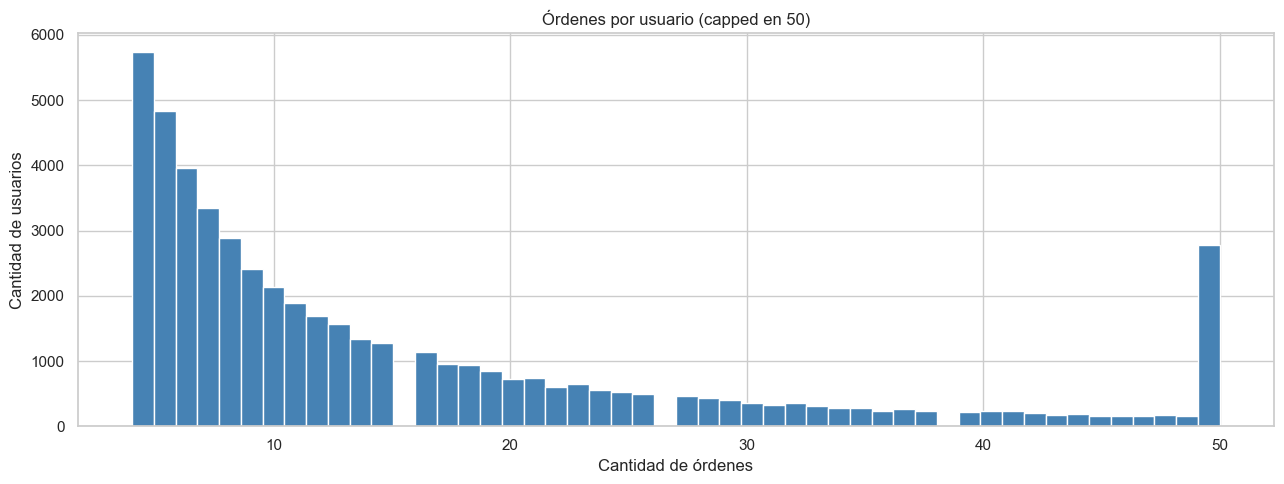

In [7]:
n_usuarios  = orders['user_id'].nunique()
n_productos = products['product_id'].nunique()
n_pares_obs = df.groupby(['user_id', 'product_id']).ngroups
sparsity    = 1 - (n_pares_obs / (n_usuarios * n_productos))

print("── Sparsity de la matriz usuario-producto ──")
print(f"  Usuarios en muestra:            {n_usuarios:>12,}")
print(f"  Productos en catálogo:          {n_productos:>12,}")
print(f"  Pares (usuario, producto) obs.: {n_pares_obs:>12,}")
print(f"  Pares posibles:                 {n_usuarios * n_productos:>12,}")
print(f"  Sparsity:                       {sparsity:>12.4%}")
print(f"\n→ Solo 1 de cada {1/(1-sparsity):.0f} pares posibles fue observado")

print("\n── Cold start ──")
print(f"  Usuarios con 1 sola orden:    {(ordenes_por_usuario == 1).sum():,} ({(ordenes_por_usuario == 1).mean():.1%})")
print(f"  Usuarios con < 5 órdenes:     {(ordenes_por_usuario < 5).sum():,} ({(ordenes_por_usuario < 5).mean():.1%})")
print(f"  Usuarios con >= 10 órdenes:   {(ordenes_por_usuario >= 10).sum():,} ({(ordenes_por_usuario >= 10).mean():.1%})")

ordenes_por_usuario.clip(upper=50).plot(kind='hist', bins=50,
                                         color='steelblue', edgecolor='white')
plt.title('Órdenes por usuario (capped en 50)')
plt.xlabel('Cantidad de órdenes')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_cold_start.png'), dpi=150)
plt.show()


### **Resultados**

#### *Sparsity*
De todos los pares (usuario, producto) posibles, solo una fracción muy
pequeña fue observada. Esta es la sparsity esperada y típica en datasets
de e-commerce: ningún usuario compra todos los productos del catálogo.

Esta alta sparsity justifica el enfoque elegido — usar un modelo
supervisado con features de interacción (LightGBM) en lugar de
filtrado colaborativo basado en factorización de matrices, que sufre
mucho con matrices muy dispersas.

#### *Cold start*
El histograma con cap en 50 órdenes muestra que una porción importante
de los usuarios tiene menos de 5 órdenes. Para estos usuarios el modelo
tiene muy poca información disponible para construir features confiables.

**Implicancia para el modelo:** DS-2 debe manejar los nulos que surgen
para usuarios con 1 sola orden en features como `user_avg_days_between_orders`
(no tienen orden anterior). Una estrategia es imputar con la mediana
global del dataset para esos casos.


---
## Sección 6 — Conclusiones y alertas para DS-2

### Cinco hallazgos clave

1. **Alta predictibilidad del comportamiento de compra (59% de recompra
   global):** más de la mitad de los productos en cualquier carrito son
   recompras. Esto valida el enfoque de next-basket recommendation y
   garantiza que el modelo tiene señal fuerte para aprender. Un sistema
   de recomendación tiene sentido de negocio claro en este contexto.

2. **Comportamiento temporal con patrones claros:** domingo y lunes
   concentran el mayor volumen de compras, y el horario pico es de
   10 a 16 hs. Esto implica que `order_dow` y `order_hour_of_day` son
   features temporales con señal real que deben incluirse en el modelo.

3. **Produce y dairy eggs dominan el volumen y la recompra:** estos dos
   departamentos concentran el mayor volumen de compras y tienen tasas
   de recompra superiores al 65%. Son el segmento donde el modelo tendrá
   mayor impacto y más señal disponible.

4. **Alta sparsity de la matriz usuario-producto:** la fracción de pares
   observados vs. posibles es muy pequeña, lo cual es típico en e-commerce.
   Esto justifica el uso de LightGBM con features de interacción en lugar
   de métodos colaborativos clásicos que no funcionan bien con matrices
   dispersas.

5. **Cold start presente en usuarios con poco historial:** una porción
   de usuarios tiene menos de 5 órdenes. Para estos usuarios las features
   basadas en historial son poco confiables o directamente nulas.
   El modelo tendrá menor precisión en este segmento.


### Variables descartadas
- `eval_set`: metadata de la competencia Kaggle, sin valor predictivo
- `order_number`: proxy directo de `user_total_orders`, no aporta información adicional

### Alertas para Feature Engineering

- **Nulos en `days_since_prior_order`:** exactamente 1 nulo por usuario (primera orden).
  Imputar con mediana global o crear flag binario `is_first_order`.

- **Filtro mínimo para tasas de recompra por producto:** usar ≥50 compras para
  que los valores sean estadísticamente representativos.

- **Reproducibilidad:** muestra generada con `random_state=42`, `n=50_000` usuarios.
  DS-2 debe usar exactamente el mismo criterio.

- **Separación prior vs. train:** `order_products_prior` es el historial
  (train del modelo) y `order_products_train` es la última orden real
  de cada usuario (target). No mezclarlos es crítico para evitar
  data leakage.

- **Tasa de recompra por departamento como feature sugerida:** el
  análisis muestra diferencias significativas entre departamentos
  (67% dairy eggs vs. 32% personal care). Considerar agregar
  `department_reorder_rate` como feature al modelo.

- **Duplicados:** se verificó que no existen filas duplicadas por par
(order_id, product_id) en order_products_prior ni en order_products_train.
La integridad de las tablas de transacciones está confirmada.

- **Outliers detectados — alertas para DS-2:**

  - **Usuarios con 100 órdenes (máximo del dataset):** el histograma de
    órdenes por usuario muestra una acumulación visible en el valor 100,
    lo que sugiere que Instacart capea el historial en ese valor. No son
    outliers reales sino un límite artificial del dataset. Para features
    como `user_total_orders`, considerar si este techo afecta el cálculo
    o si conviene documentarlo como limitación del modelo.

  - **Órdenes con más de 40 productos:** la distribución del tamaño del
    carrito tiene cola larga con casos extremos por encima de 40 productos.
    Representan una fracción muy pequeña del total pero pueden inflar
    features como `user_avg_basket_size` para esos usuarios. Sugerencia:
    calcular la feature con y sin estos casos y evaluar el impacto antes
    de decidir si capear o mantener.

  - **Usuarios con alta frecuencia de compra (más de 1000 productos
    comprados totales):** visible en el scatterplot de frecuencia vs.
    tasa de recompra. Estos usuarios tienen comportamiento muy estable
    y alta tasa de recompra, lo cual es buena señal para el modelo.
    No se recomienda excluirlos — son los usuarios más predecibles.

  - **Criterio general sugerido para DS-2:** antes de capear o excluir
    cualquier outlier, verificar si afecta la distribución de la feature
    calculada (comparar media vs. mediana). Si la diferencia es grande,
    considerar usar la mediana.